In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from pathlib import Path

In [2]:
RESULTS_DIR = Path("/home/vivekbisht/Desktop/faers-signal-detection/results_private")
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14,8)


In [4]:
validation_res= pd.read_csv("/home/vivekbisht/Desktop/faers-signal-detection/results_private/semantic_enhanced_validation.csv")

In [6]:
validation_res['baseline_prr'] = (
    validation_res['prr'] *
    (validation_res['pooled_cases'] / validation_res['pooled_cases'])  # placeholder
)

KeyError: 'enhanced_prr'

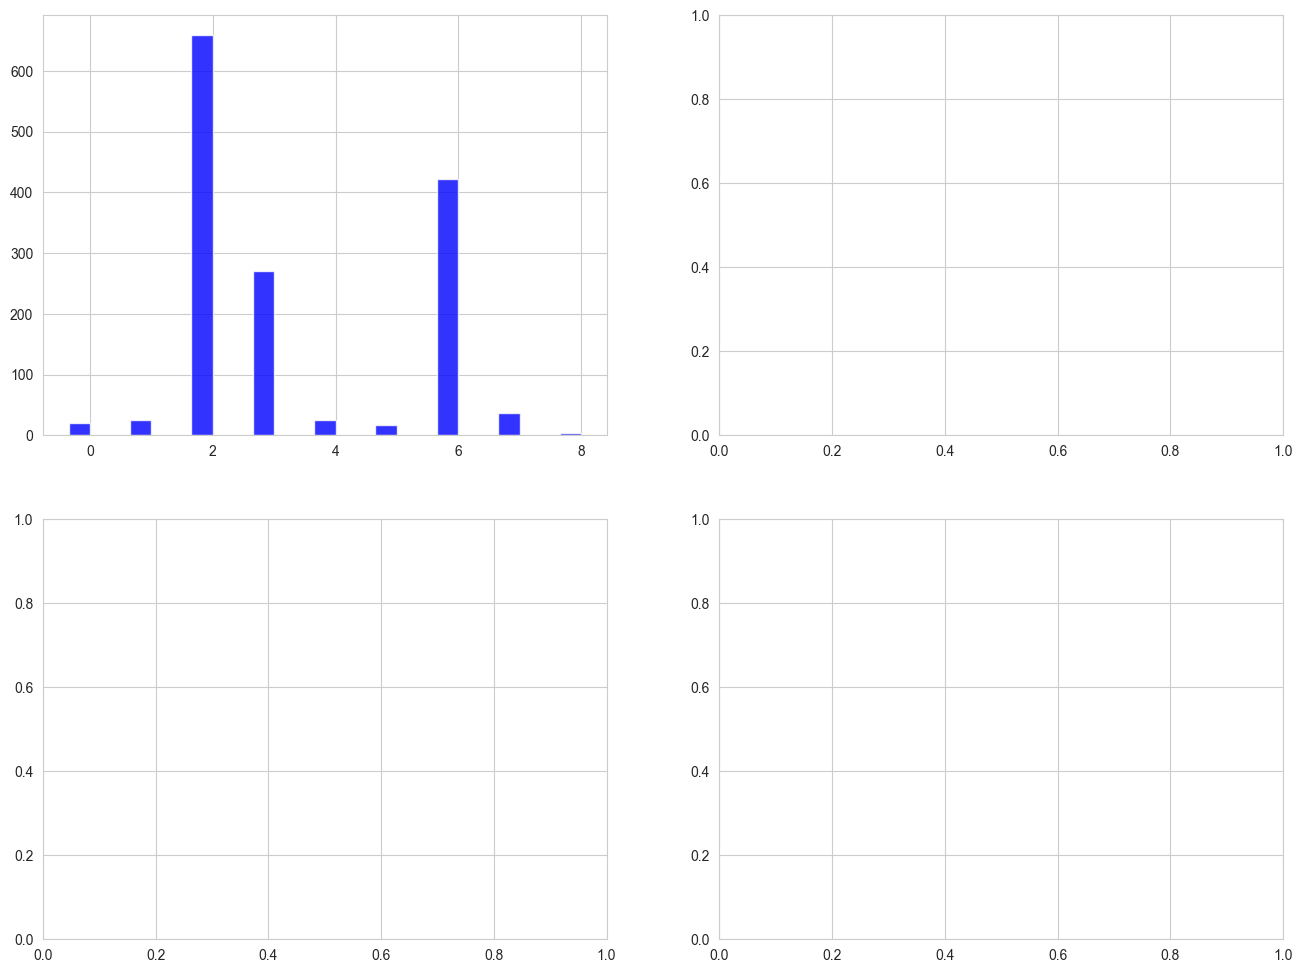

In [7]:
fig,axes = plt.subplots(2,2,figsize=(16,12))

ax1 = axes[0,0] 
xp = np.arange(len(validation_res))
width = .35


ax1.bar(xp-width/2,validation_res['prr']  ,width , label='Baseline Prr', alpha=.8 ,color='blue')
ax1.bar(xp+width/2 , validation_res['enhanced_prr'] , width , label="enhanced_prr",alpha =.8 , color ='coral')

ax1.set_label("Validation_cases")
ax1.set_ylabel("PRR Value" , fontsize=12,fontweight = 'bold')
ax1.set_title("baseline vs Sematic PRR" , fontsize= '14' , fontweight='bold')




ax2 = axes[0, 1]
colors_improvement = ['green' if x > 0 else 'gray' for x in validation_res['improvement']]

ax2.barh(range(len(validation_res)), validation_res['improvement'], 
         color=colors_improvement, alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(validation_res)))
ax2.set_yticklabels([f"{row['drug'][:15]}" for _, row in validation_res.iterrows()], 
                     fontsize=10)
ax2.set_xlabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Percentage Improvement by Case', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax2.grid(axis='x', alpha=0.3)

for i, (_, row) in enumerate(validation_res.iterrows()):
    if row['improvement'] > 0:
        ax2.text(row['improvement'] + 0.1, i, f"+{row['improvement']:.1f}%", 
                va='center', fontsize=9, fontweight='bold')